Step by step decouple 
- `mlfromscratch/examples/linear_regression.py`
- `mlfromscratch/supervised_learning/regression.py`

# Import

In [6]:
import os
import sys
sys.path.insert(0, "../..")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

from mlfromscratch.utils import k_fold_cross_validation_sets, normalize, mean_squared_error
from mlfromscratch.utils import train_test_split, polynomial_features, Plot

# enable automatic reloading of Python modules
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Create Dataset

In [7]:
from sklearn.datasets import make_regression
X, y = make_regression(n_samples=1000, n_features=1, noise=10, bias=0, random_state=42)

In [8]:
X[:5], y[:5]

(array([[-1.75873949],
        [ 1.03184454],
        [-0.48760622],
        [ 0.18645431],
        [ 0.72576662]]),
 array([-32.77038605,   3.50459106, -17.93030767,  -3.99020124,
         13.10526434]))

## Plot data

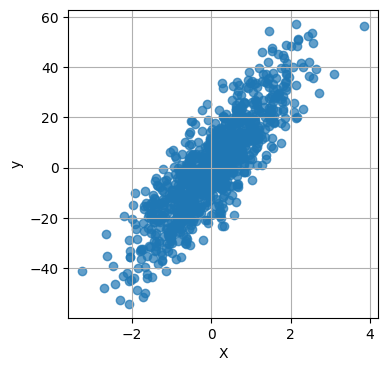

In [9]:
plt.figure(figsize=(4, 4))
plt.scatter(X.ravel(), y, alpha=0.7)
plt.xlabel("X")
plt.ylabel("y")
plt.grid(True)
plt.show()

## Preprocess

In [10]:
# do a train test split with shuffle
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

# Fit

## Add Constant

In [11]:
# Insert constant ones for bias weights
print(X_train[:10])
X_train = np.insert(X_train, 0, 1, axis=1)
print(X_train[:10])

[[-0.63738713]
 [ 0.19808476]
 [ 0.06428002]
 [-0.53086877]
 [ 3.85273149]
 [-1.43014138]
 [-1.71016839]
 [ 0.18660912]
 [-0.05023811]
 [ 0.58831721]]
[[ 1.         -0.63738713]
 [ 1.          0.19808476]
 [ 1.          0.06428002]
 [ 1.         -0.53086877]
 [ 1.          3.85273149]
 [ 1.         -1.43014138]
 [ 1.         -1.71016839]
 [ 1.          0.18660912]
 [ 1.         -0.05023811]
 [ 1.          0.58831721]]


## Method 1: Least Square

https://en.wikipedia.org/wiki/Moore%E2%80%93Penrose_inverse

The most stable and common way to compute the Moore-Penrose pseudoinverse is by using the singular value decomposition (SVD) - decouple matrix X into U, S, V

- **\(U\):** A unitary matrix (or orthogonal for real matrices) whose columns are the left singular vectors of \(X\). 
- **\(S\)**: A diagonal matrix containing the singular values of \(X\) along its diagonal, sorted in non-increasing order. np.linalg.svd returns these singular values as a 1D array s. 
- **\(V^{H}\)**: The conjugate transpose of a unitary matrix (V\) (or transpose for real matrices), whose rows are the right singular vectors of \(X\). np.linalg.svd returns this matrix directly as vh.

In [12]:
# Calculate weights by least squares (using Moore-Penrose pseudoinverse)
U, S, V = np.linalg.svd(X_train.T.dot(X_train))
S = np.diag(S)
X_sq_reg_inv = V.dot(np.linalg.pinv(S)).dot(U.T)

for a_name, a in zip(["U", "S", "V"], [U, S, V]):
    print(f"==={a_name}===")
    print(a)
    print("Shape: ", a.shape)
    print()

===U===
[[-0.86899142 -0.49482715]
 [-0.49482715  0.86899142]]
Shape:  (2, 2)

===S===
[[814.97879941   0.        ]
 [  0.         753.80436448]]
Shape:  (2, 2)

===V===
[[-0.86899142 -0.49482715]
 [-0.49482715  0.86899142]]
Shape:  (2, 2)



In [13]:
print(X_sq_reg_inv)

[[ 1.25140794e-03 -4.28187531e-05]
 [-4.28187531e-05  1.30222200e-03]]


In [14]:
# update weight
w_train = X_sq_reg_inv.dot(X_train.T).dot(y_train)
print("constant", "beta")
print(w_train)

constant beta
[ 0.0197541  16.83346987]


## Method 2: Gradient Descent

Init weight using Xavier/Glorot initialization to prevent gradient explosion and maintain variance

In [15]:
# init training error and iterations
n_features = X_train.shape[1]
print("Num of features: ", n_features)

# # randomly init w_train
limit = 1 / math.sqrt(n_features)
rng = np.random.default_rng(42)

w_train = np.random.uniform(-limit, limit, (n_features, ))

print("Randomly init-ed weights:")
print(w_train)

Num of features:  2
Randomly init-ed weights:
[0.64417551 0.60187411]


In [16]:
# Do gradient descent for n_iterations
n_iterations = 100
learning_rate = 0.0001
regularization = lambda x: 0
regularization.grad = lambda x: 0
training_errors = []

for i in range(n_iterations):
    y_pred = X_train.dot(w_train)
    # Calculate l2 loss
    mse = np.mean(0.5 * (y_train - y_pred)**2 + regularization(w_train))
    training_errors.append(mse)
    # Gradient of l2 loss w.r.t w
    grad_w = -(y_train - y_pred).dot(X_train) + regularization.grad(w_train)
    
    # Update the weights
    w_train -= learning_rate * grad_w

Text(0, 0.5, 'loss (L2 MSE)')

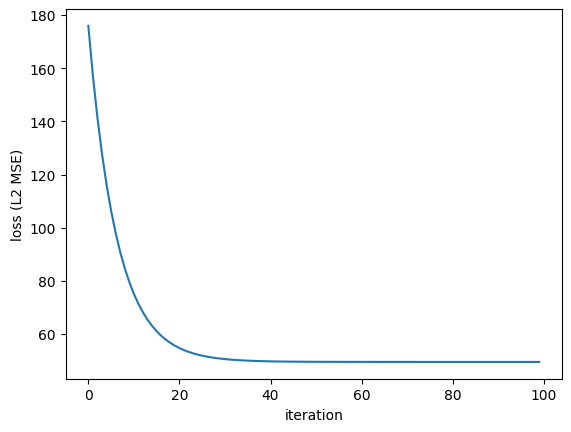

In [17]:
g = sns.lineplot(x=np.linspace(0, n_iterations - 1, 100), y=training_errors)
g.set_xlabel("iteration")
g.set_ylabel("loss (L2 MSE)")

Notice this `w_train` is very similar to the one got using least square SVD in method 1

In [18]:
w_train

array([ 0.02124684, 16.82777231])

**Why SVD Least Square is better**: SVD solves the normal equation `(X^T X)w = X^T` y directly by computing the pseudoinverse of `X^T X`. This gives the closed-form solution `w = (X^T X)^(-1) X^T y` in one step, whereas gradient descent iteratively approximates it. 

# E2E

In [19]:
from mlfromscratch.supervised_learning import LinearRegression

In [20]:
n_samples, n_features = np.shape(X)
model = LinearRegression(n_iterations=100, learning_rate=learning_rate)
model.fit(X_train, y_train)

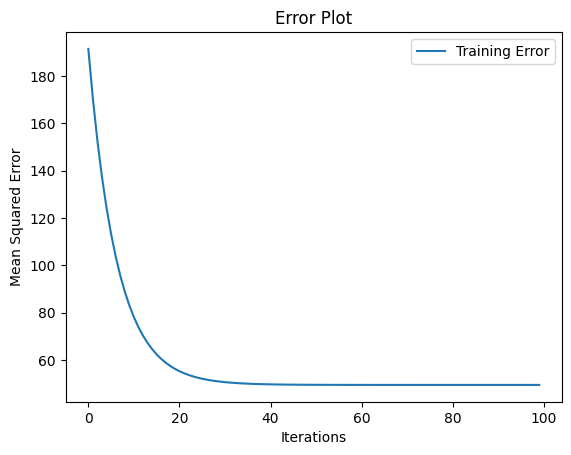

In [21]:
# Training error plot
n = len(model.training_errors)
training, = plt.plot(range(n), model.training_errors, label="Training Error")
plt.legend(handles=[training])
plt.title("Error Plot")
plt.ylabel('Mean Squared Error')
plt.xlabel('Iterations')
plt.show()

In [26]:
# create y_pred for test dataset
y_pred = model.predict(np.insert(X_test, 0, 1, axis=1))

# calculate R² (coefficient of determination)
ss_res = np.sum((y_test - y_pred) ** 2)  # residual sum of squares
ss_tot = np.sum((y_test - np.mean(y_test)) ** 2)  # total sum of squares
r2_score = 1 - (ss_res / ss_tot)
print(f"R² Score: {r2_score:.4f}")

R² Score: 0.7142


In [ ]:
# calc MSE
mse = ss_res / len(X_test)
# or you can use:
# mse = mean_squared_error(y_test, y_pred)
print ("Mean squared error: %s" % (mse))

Mean squared error: 94.48921706916026


- $R^2$ explains what percentage of the variance in a y is explained by the X
    - By comparing two things: the error of the model, and the error of a "baseline", which in this case is the assumption to perdict y WITHOUT X
    - `ss_tot` (SST) in this case creates the baseline: The most logical and common "baseline" guess is simply the average (or mean) of all the y values.
    - `ss_res` (SSR) is the sum of squared residual from our model
    - $R^2 = 1 - \frac{SSR}{SST}$
- The biggest limitation of $R^2$ is that it can be misleading when you **add more independent variables** ($X$) to your model.
    - $R^2$ will always increase (or stay the same) every time you add a new $X$ variable.
    - It never goes down, even if the variable you add is completely useless.
    - Mainly becasue `ss_tot` is fixed.
    - Not a very good metric to evaluate a complicated model of the "effciency" of a model.
- **Adjusted $R^2$** is defined to overcome this
    - $R_{Adjusted}^2 = 1 - \frac{SSR / (n-k-1)}{SST / (n-1)}$
    - See `polynomial_regression` notebook for more details

## Show pred results

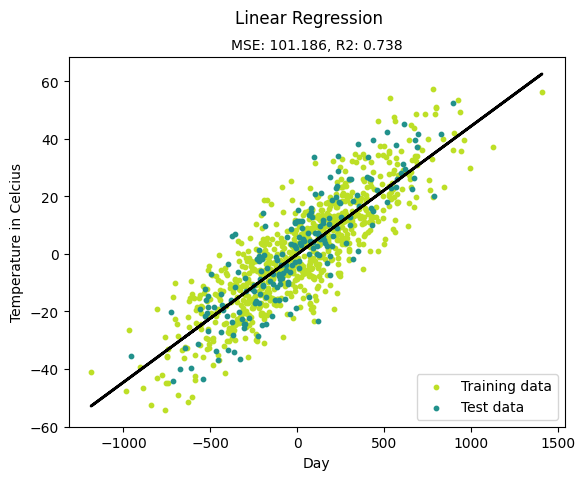

In [ ]:
y_pred_line = model.predict(X)

# Color map
cmap = plt.get_cmap('viridis')

# Plot the results
m1 = plt.scatter(366 * X_train, y_train, color=cmap(0.9), s=10)
m2 = plt.scatter(366 * X_test, y_test, color=cmap(0.5), s=10)
plt.plot(366 * X, y_pred_line, color='black', linewidth=2, label="Prediction")
plt.suptitle("Linear Regression")
plt.title(f"Test Results MSE: {mse:.3f}, R2: {r2_score:.3f}", fontsize=10)
plt.xlabel('Day')
plt.ylabel('Temperature in Celcius')
plt.legend((m1, m2), ("Training data", "Test data"), loc='lower right')
plt.show()